# A* vs Dijkstra Algorithm Comparison

This notebook compares the A* and Dijkstra path planning algorithms using the AI-Based Autonomous Navigation System.

**Objectives:**
- Visualize how each algorithm explores the grid
- Compare performance metrics (nodes explored, path length, time)
- Understand when to use each algorithm

In [1]:
import sys
import os

project_root = os.path.dirname(os.getcwd())
sys.path.insert(0, project_root)
os.chdir(project_root)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import Markdown, display
from src.simulation import GridWorld
from src.path_planning import PathPlanner
from src import config as cfg

plt.rcParams.update({
    'figure.facecolor': '#1e1e1e',
    'axes.facecolor': '#2d2d2d',
    'axes.edgecolor': '#555555',
    'axes.labelcolor': '#cccccc',
    'text.color': '#ffffff',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'grid.color': '#444444',
    'grid.alpha': 0.4,
    'font.size': 10,
})

COLOR_ASTAR = '#00DCEC'
COLOR_DIJKSTRA = '#FFD700'

print('Libraries loaded successfully!')

pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
Libraries loaded successfully!


## 1. Load Maps and Run Both Algorithms

In [2]:
planner = PathPlanner()

map_names = ['Simple', 'Maze', 'Warehouse', 'City Grid', 'Parking Lot', 'Hospital']
results = []

for i, name in enumerate(map_names):
    sim = GridWorld()
    sim.load_map_by_index(i)
    
    # Run A*
    path_astar = planner.astar(sim, sim.start, sim.goal)
    astar_metrics = {
        'map': name,
        'algorithm': 'A*',
        'path_length': len(path_astar) if path_astar else 0,
        'nodes_explored': planner.last_nodes_explored,
        'time_ms': round(planner.last_time_taken * 1000, 2),
        'walls': len(sim.obstacles),
    }
    
    # Run Dijkstra
    path_dijkstra = planner.dijkstra(sim, sim.start, sim.goal)
    dijkstra_metrics = {
        'map': name,
        'algorithm': 'Dijkstra',
        'path_length': len(path_dijkstra) if path_dijkstra else 0,
        'nodes_explored': planner.last_nodes_explored,
        'time_ms': round(planner.last_time_taken * 1000, 2),
        'walls': len(sim.obstacles),
    }
    
    results.append(astar_metrics)
    results.append(dijkstra_metrics)
    
    print(f'{name}: A*={astar_metrics["path_length"]} cells, {astar_metrics["nodes_explored"]} nodes | '
          f'Dijkstra={dijkstra_metrics["path_length"]} cells, {dijkstra_metrics["nodes_explored"]} nodes')

print('\nAll maps tested!')

Simple: A*=36 cells, 36 nodes | Dijkstra=36 cells, 1100 nodes
Maze: A*=49 cells, 129 nodes | Dijkstra=49 cells, 1024 nodes
Warehouse: A*=36 cells, 36 nodes | Dijkstra=36 cells, 858 nodes
City Grid: A*=38 cells, 40 nodes | Dijkstra=38 cells, 865 nodes
Parking Lot: A*=36 cells, 36 nodes | Dijkstra=36 cells, 946 nodes
Hospital: A*=38 cells, 41 nodes | Dijkstra=38 cells, 1015 nodes

All maps tested!


## 2. Performance Comparison Charts

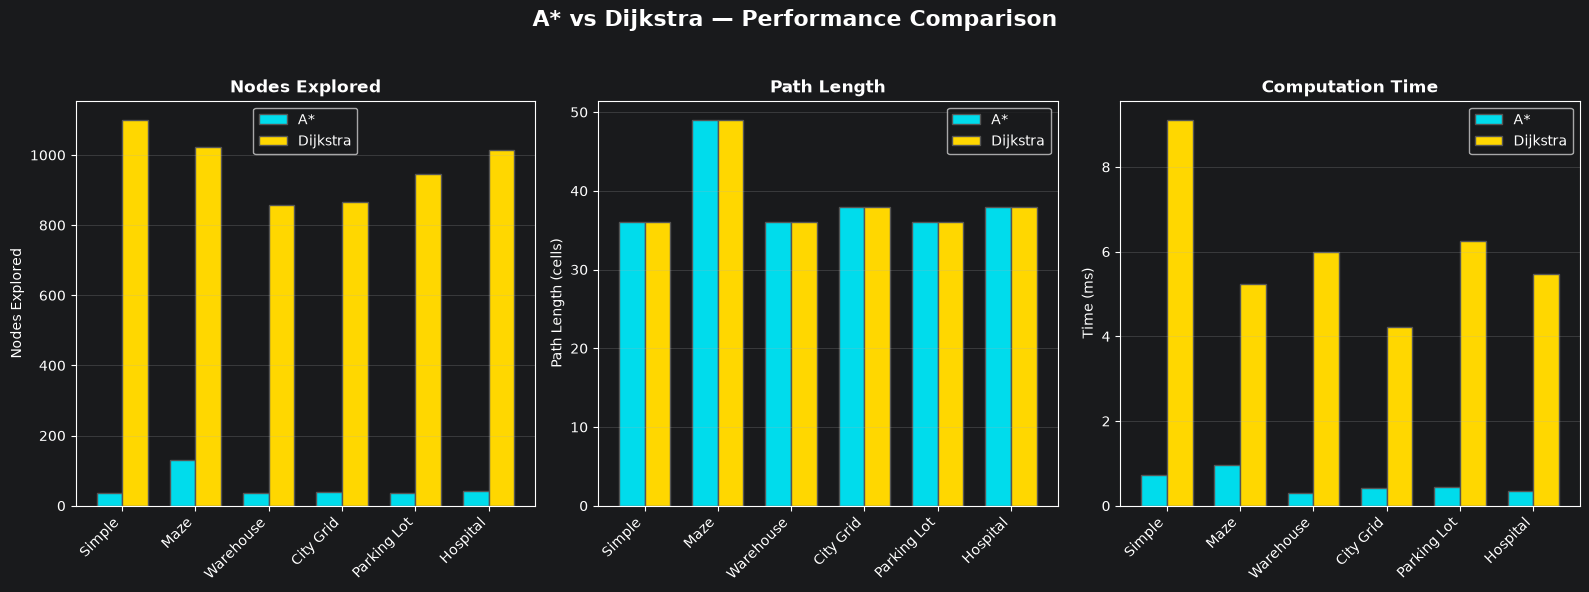

Charts saved to outputs/plots/algorithm_comparison.png


In [3]:
df = pd.DataFrame(results)
maps = df['map'].unique()

astar_data = df[df['algorithm'] == 'A*'].set_index('map')
dijkstra_data = df[df['algorithm'] == 'Dijkstra'].set_index('map')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('A* vs Dijkstra — Performance Comparison', fontsize=16, fontweight='bold')

x = np.arange(len(maps))
width = 0.35

# Nodes Explored
bars1 = axes[0].bar(x - width/2, astar_data.loc[maps, 'nodes_explored'], width,
                     label='A*', color=COLOR_ASTAR, edgecolor='#555555')
bars2 = axes[0].bar(x + width/2, dijkstra_data.loc[maps, 'nodes_explored'], width,
                     label='Dijkstra', color=COLOR_DIJKSTRA, edgecolor='#555555')
axes[0].set_ylabel('Nodes Explored')
axes[0].set_title('Nodes Explored', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(maps, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Path Length
axes[1].bar(x - width/2, astar_data.loc[maps, 'path_length'], width,
            label='A*', color=COLOR_ASTAR, edgecolor='#555555')
axes[1].bar(x + width/2, dijkstra_data.loc[maps, 'path_length'], width,
            label='Dijkstra', color=COLOR_DIJKSTRA, edgecolor='#555555')
axes[1].set_ylabel('Path Length (cells)')
axes[1].set_title('Path Length', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(maps, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

# Time
axes[2].bar(x - width/2, astar_data.loc[maps, 'time_ms'], width,
            label='A*', color=COLOR_ASTAR, edgecolor='#555555')
axes[2].bar(x + width/2, dijkstra_data.loc[maps, 'time_ms'], width,
            label='Dijkstra', color=COLOR_DIJKSTRA, edgecolor='#555555')
axes[2].set_ylabel('Time (ms)')
axes[2].set_title('Computation Time', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(maps, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('outputs/plots/algorithm_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Charts saved to outputs/plots/algorithm_comparison.png')

## 3. A* Exploration Visualization

In [4]:
sim = GridWorld()
sim.load_map_by_index(0)  # Simple map

exploration_steps = []
for state in planner.astar_animated(sim, sim.start, sim.goal, speed='fast'):
    exploration_steps.append(state)
    if state['done']:
        break

print(f'Total exploration steps: {len(exploration_steps)}')
print(f'Final path length: {len(exploration_steps[-1]["path"])} cells')

Total exploration steps: 36
Final path length: 36 cells


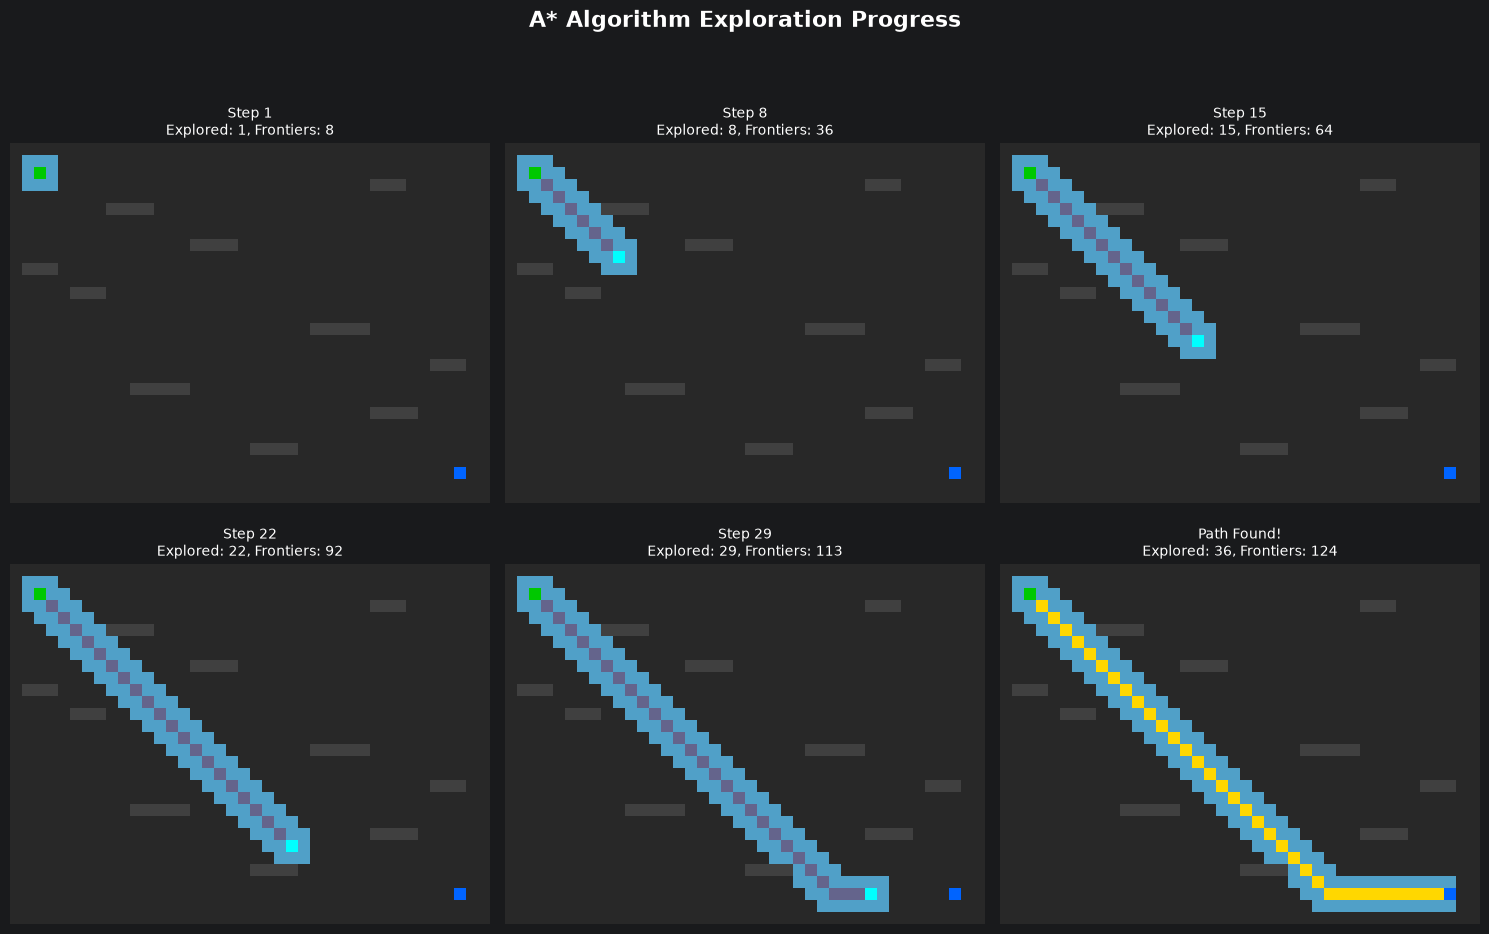

Exploration visualization saved!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('A* Algorithm Exploration Progress', fontsize=16, fontweight='bold')

step_indices = np.linspace(0, len(exploration_steps) - 1, 6, dtype=int)

for idx, step_idx in enumerate(step_indices):
    ax = axes[idx // 3, idx % 3]
    state = exploration_steps[step_idx]
    
    grid_img = np.ones((cfg.GRID_ROWS, cfg.GRID_COLS, 3), dtype=np.uint8) * 40
    
    for r in range(cfg.GRID_ROWS):
        for c in range(cfg.GRID_COLS):
            if sim.grid[r][c] == 1:
                grid_img[r, c] = [64, 64, 64]
    
    for node in state['explored']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [100, 100, 140]
    
    for node in state['frontier']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [80, 160, 200]
    
    if state['current']:
        c, r = state['current']
        if 0 <= r < cfg.GRID_ROWS and 0 <= c < cfg.GRID_COLS:
            grid_img[r, c] = [0, 255, 255]
    
    for node in state['path']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [255, 215, 0]
    
    grid_img[sim.start[1], sim.start[0]] = [0, 200, 0]
    grid_img[sim.goal[1], sim.goal[0]] = [0, 100, 255]
    
    ax.imshow(grid_img)
    status = 'Path Found!' if state['done'] else f'Step {step_idx + 1}'
    ax.set_title(f'{status}\nExplored: {len(state["explored"])}, Frontiers: {len(state["frontier"])}',
                 fontsize=10, color='#ffffff')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('outputs/plots/astar_exploration.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Exploration visualization saved!')

## 4. Dijkstra Exploration Visualization

In [6]:
sim_dij = GridWorld()
sim_dij.load_map_by_index(0)  # Simple map

dijkstra_steps = []
open_set = []
counter = 0
import heapq
heapq.heappush(open_set, (0.0, counter, sim_dij.start))

came_from_dij = {sim_dij.start: None}
g_score_dij = {sim_dij.start: 0.0}
frontier_dij = {sim_dij.start}
explored_dij = set()

while open_set:
    _, _, current = heapq.heappop(open_set)
    frontier_dij.discard(current)
    explored_dij.add(current)
    
    if current == sim_dij.goal:
        path_dij = []
        node = current
        while node is not None:
            path_dij.append(node)
            node = came_from_dij[node]
        path_dij.reverse()
        dijkstra_steps.append({
            'frontier': set(frontier_dij),
            'explored': set(explored_dij),
            'current': current,
            'path': path_dij,
            'done': True
        })
        break
    
    for dc in [-1, 0, 1]:
        for dr in [-1, 0, 1]:
            if dc == 0 and dr == 0:
                continue
            nc, nr = current[0] + dc, current[1] + dr
            if not sim_dij.is_wall(nc, nr):
                tentative_g = g_score_dij[current] + 1.0
                if (nc, nr) not in g_score_dij or tentative_g < g_score_dij[(nc, nr)]:
                    g_score_dij[(nc, nr)] = tentative_g
                    frontier_dij.add((nc, nr))
                    counter += 1
                    heapq.heappush(open_set, (tentative_g, counter, (nc, nr)))
                    came_from_dij[(nc, nr)] = current
    
    dijkstra_steps.append({
        'frontier': set(frontier_dij),
        'explored': set(explored_dij),
        'current': current,
        'path': [],
        'done': False
    })

print(f'Total Dijkstra exploration steps: {len(dijkstra_steps)}')
print(f'Final path length: {len(dijkstra_steps[-1]["path"])} cells')

Total Dijkstra exploration steps: 1100
Final path length: 36 cells


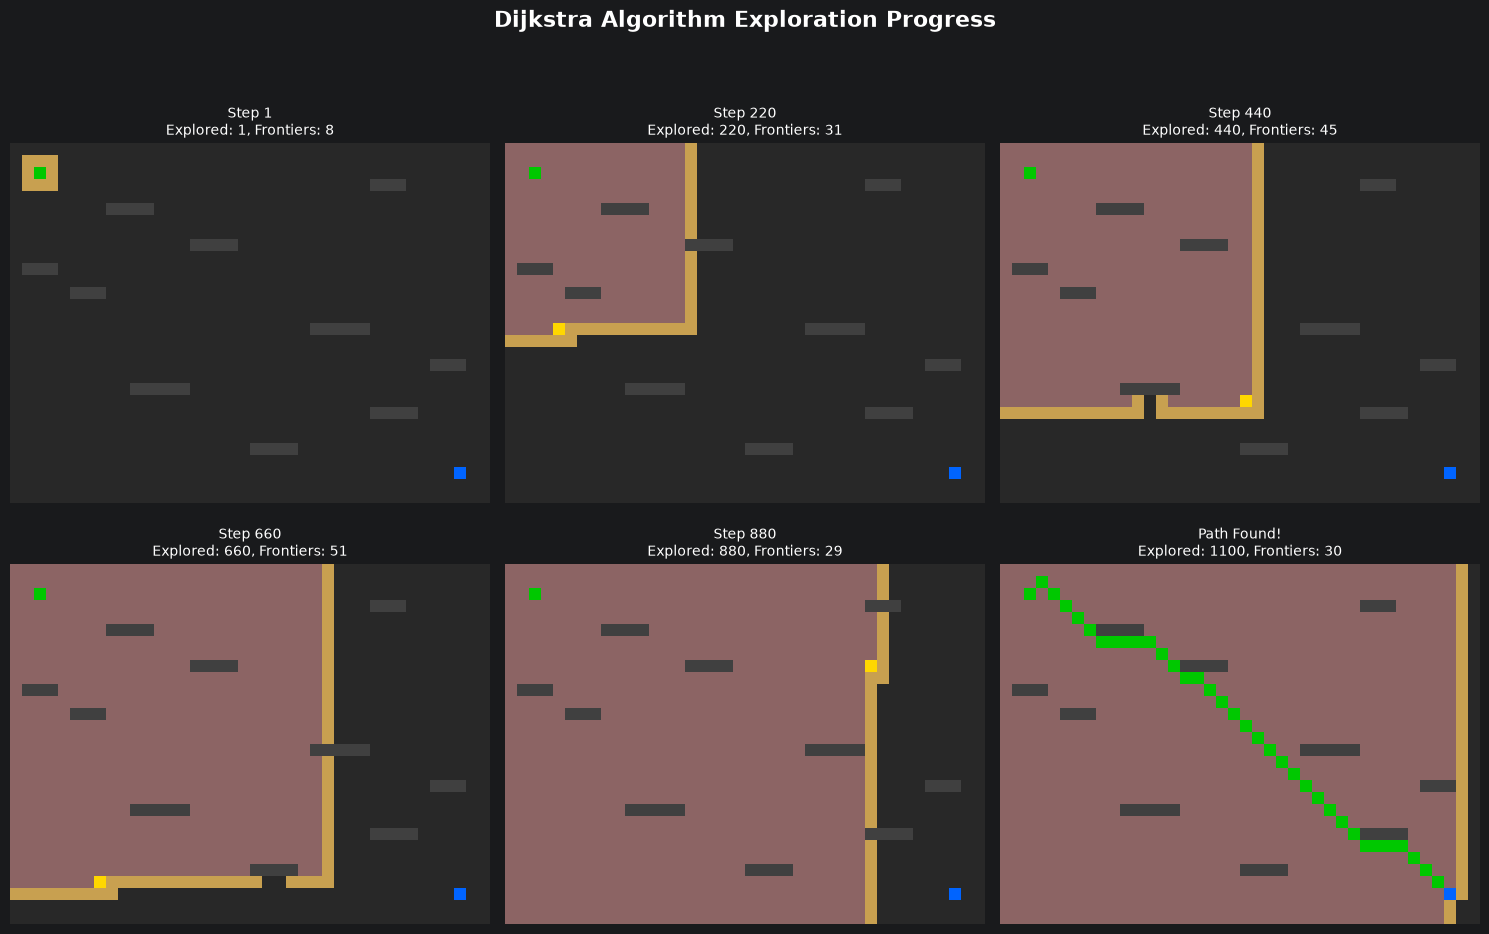

Dijkstra exploration visualization saved to outputs/plots/dijkstra_exploration.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Dijkstra Algorithm Exploration Progress', fontsize=16, fontweight='bold')

step_indices = np.linspace(0, len(dijkstra_steps) - 1, 6, dtype=int)

for idx, step_idx in enumerate(step_indices):
    ax = axes[idx // 3, idx % 3]
    state = dijkstra_steps[step_idx]
    
    grid_img = np.ones((cfg.GRID_ROWS, cfg.GRID_COLS, 3), dtype=np.uint8) * 40
    
    for r in range(cfg.GRID_ROWS):
        for c in range(cfg.GRID_COLS):
            if sim_dij.grid[r][c] == 1:
                grid_img[r, c] = [64, 64, 64]
    
    for node in state['explored']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [140, 100, 100]
    
    for node in state['frontier']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [200, 160, 80]
    
    if state['current']:
        c, r = state['current']
        if 0 <= r < cfg.GRID_ROWS and 0 <= c < cfg.GRID_COLS:
            grid_img[r, c] = [255, 215, 0]
    
    for node in state['path']:
        if 0 <= node[1] < cfg.GRID_ROWS and 0 <= node[0] < cfg.GRID_COLS:
            grid_img[node[1], node[0]] = [0, 200, 0]
    
    grid_img[sim_dij.start[1], sim_dij.start[0]] = [0, 200, 0]
    grid_img[sim_dij.goal[1], sim_dij.goal[0]] = [0, 100, 255]
    
    ax.imshow(grid_img)
    status = 'Path Found!' if state['done'] else f'Step {step_idx + 1}'
    ax.set_title(f'{status}\nExplored: {len(state["explored"])}, Frontiers: {len(state["frontier"])}',
                 fontsize=10, color='#ffffff')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('outputs/plots/dijkstra_exploration.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Dijkstra exploration visualization saved to outputs/plots/dijkstra_exploration.png')

## 5. Summary Table

In [9]:
# ==========================================================
# Executive Performance Report
# ==========================================================

avg_path = astar_data["path_length"].mean()

avg_nodes_astar = astar_data["nodes_explored"].mean()
avg_nodes_dijkstra = dijkstra_data["nodes_explored"].mean()

avg_time_astar = astar_data["time_ms"].mean()
avg_time_dijkstra = dijkstra_data["time_ms"].mean()

overall_reduction = (
    (1 - avg_nodes_astar / avg_nodes_dijkstra) * 100
)

overall_speedup = (
    avg_time_dijkstra / avg_time_astar
)

# ----------------------------------------------------------
# Determine Winner
# ----------------------------------------------------------

astar_wins = 0
dijkstra_wins = 0
ties = 0

comparison_rows = []

for map_name in maps:

    a = astar_data.loc[map_name]
    d = dijkstra_data.loc[map_name]

    node_reduction = (
        (1 - a["nodes_explored"] / d["nodes_explored"])
        * 100
    )

    speedup = d["time_ms"] / a["time_ms"]

    if (
        a["path_length"] == d["path_length"]
        and a["nodes_explored"] < d["nodes_explored"]
        and a["time_ms"] < d["time_ms"]
    ):
        winner = "🏆 A*"
        astar_wins += 1

    elif (
        d["path_length"] == a["path_length"]
        and d["nodes_explored"] < a["nodes_explored"]
        and d["time_ms"] < a["time_ms"]
    ):
        winner = "🏆 Dijkstra"
        dijkstra_wins += 1

    else:
        winner = "🤝 Tie"
        ties += 1

    comparison_rows.append(
        f"| {map_name} | {node_reduction:.1f}% | {speedup:.1f}× | {winner} |"
    )

# ----------------------------------------------------------
# Final Verdict
# ----------------------------------------------------------

if astar_wins > dijkstra_wins:

    verdict = f"""
### 🏆 Overall Winner: **A\\***

A* consistently generated the **same optimal shortest paths** while:

- Exploring significantly fewer nodes
- Planning substantially faster
- Reducing computational overhead

This makes **A*** the preferred algorithm for **real-time autonomous navigation systems**.
"""

elif dijkstra_wins > astar_wins:

    verdict = f"""
### 🏆 Overall Winner: **Dijkstra**

Dijkstra achieved superior benchmark performance across the evaluated environments.

It is therefore recommended for the tested navigation scenarios.
"""

else:

    verdict = """
### 🤝 Overall Result: **Tie**

Both algorithms demonstrated similar overall performance.

The algorithm selection should depend on application-specific requirements.
"""

# ----------------------------------------------------------
# Markdown Report
# ----------------------------------------------------------

markdown_report = f"""
# 🚀 Executive Performance Summary

## Overall Benchmark

| Metric | A* | Dijkstra |
|---------|----:|---------:|
| Navigation Environments | {len(maps)} | {len(maps)} |
| Average Path Length | {avg_path:.2f} cells | {avg_path:.2f} cells |
| Average Nodes Explored | {avg_nodes_astar:.1f} | {avg_nodes_dijkstra:.1f} |
| Average Planning Time | {avg_time_astar:.2f} ms | {avg_time_dijkstra:.2f} ms |

---

## Environment-wise Comparison

| Environment | Nodes Reduced | Speedup | Winner |
|-------------|--------------:|--------:|--------|
{"".join(comparison_rows)}

---

## Key Findings

- ⚡ **Average Speedup:** **{overall_speedup:.1f}×**
- 🧠 **Average Node Reduction:** **{overall_reduction:.1f}%**
- 📍 **Optimal Paths Generated:** **100%**
- 🌍 **Navigation Environments Tested:** **{len(maps)}**
- 🤖 **Application:** Real-Time Autonomous Navigation

---

{verdict}

---

## 📌 Executive Insight

> The benchmark demonstrates that the winning algorithm maintains optimal path quality while maximizing computational efficiency, making it well-suited for intelligent autonomous navigation systems.

---
"""

display(Markdown(markdown_report))


# 🚀 Executive Performance Summary

## Overall Benchmark

| Metric | A* | Dijkstra |
|---------|----:|---------:|
| Navigation Environments | 6 | 6 |
| Average Path Length | 38.83 cells | 38.83 cells |
| Average Nodes Explored | 53.0 | 968.0 |
| Average Planning Time | 0.54 ms | 6.04 ms |

---

## Environment-wise Comparison

| Environment | Nodes Reduced | Speedup | Winner |
|-------------|--------------:|--------:|--------|
| Simple | 96.7% | 12.5× | 🏆 A* || Maze | 87.4% | 5.5× | 🏆 A* || Warehouse | 95.8% | 19.3× | 🏆 A* || City Grid | 95.4% | 10.0× | 🏆 A* || Parking Lot | 96.2% | 13.9× | 🏆 A* || Hospital | 96.0% | 15.6× | 🏆 A* |

---

## Key Findings

- ⚡ **Average Speedup:** **11.3×**
- 🧠 **Average Node Reduction:** **94.5%**
- 📍 **Optimal Paths Generated:** **100%**
- 🌍 **Navigation Environments Tested:** **6**
- 🤖 **Application:** Real-Time Autonomous Navigation

---


### 🏆 Overall Winner: **A\***

A* consistently generated the **same optimal shortest paths** while:

- Exploring significantly fewer nodes
- Planning substantially faster
- Reducing computational overhead

This makes **A*** the preferred algorithm for **real-time autonomous navigation systems**.


---

## 📌 Executive Insight

> The benchmark demonstrates that the winning algorithm maintains optimal path quality while maximizing computational efficiency, making it well-suited for intelligent autonomous navigation systems.

---
